In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
# Loading datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [5]:
sentiment.columns = sentiment.columns.str.lower().str.strip()
trades.columns = trades.columns.str.lower().str.strip()

print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')


In [6]:
# sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# trades timestamp
trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'],
    format='%d-%m-%Y %H:%M'
)

# create daily date
trades['date'] = trades['timestamp ist'].dt.date

In [7]:
trades = trades.rename(columns={
    'closed pnl': 'closedpnl',
    'size usd': 'size_usd'
})

sentiment = sentiment.rename(columns={
    'classification': 'sentiment'
})

In [8]:
print("Sentiment Missing Values:")
print(sentiment.isnull().sum())

print("\nTrades Missing Values:")
print(trades.isnull().sum())

Sentiment Missing Values:
timestamp    0
value        0
sentiment    0
date         0
dtype: int64

Trades Missing Values:
account             0
coin                0
execution price     0
size tokens         0
size_usd            0
side                0
timestamp ist       0
start position      0
direction           0
closedpnl           0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
date                0
dtype: int64


In [9]:
trades = trades.drop_duplicates()

In [10]:
merged = pd.merge(
    trades,
    sentiment[['date', 'sentiment']],
    on='date',
    how='left'
)

print(merged[['date', 'sentiment']].head())

         date      sentiment
0  2024-12-02  Extreme Greed
1  2024-12-02  Extreme Greed
2  2024-12-02  Extreme Greed
3  2024-12-02  Extreme Greed
4  2024-12-02  Extreme Greed


In [11]:
merged = merged[merged['closedpnl'] != 0]

In [12]:
merged['win'] = merged['closedpnl'] > 0

In [13]:
merged['is_long'] = merged['side'] == 'BUY'

In [14]:
merged['leverage'] = merged['size_usd'] / (merged['execution price'] * merged['size tokens'])

In [15]:
daily_pnl = merged.groupby(['account', 'date'])['closedpnl'].sum().reset_index()

In [16]:
daily_trades = merged.groupby('date').size().reset_index(name='num_trades')

In [17]:
avg_trade_size = merged.groupby('date')['size_usd'].mean().reset_index(name='avg_trade_size')

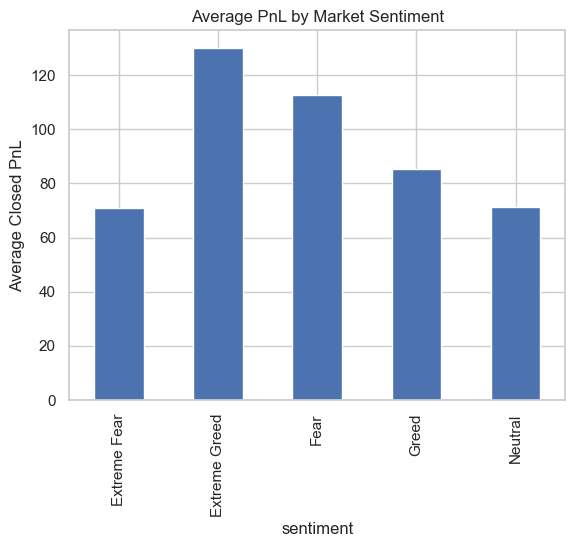

In [18]:
pnl_by_sentiment = merged.groupby('sentiment')['closedpnl'].mean()

pnl_by_sentiment.plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

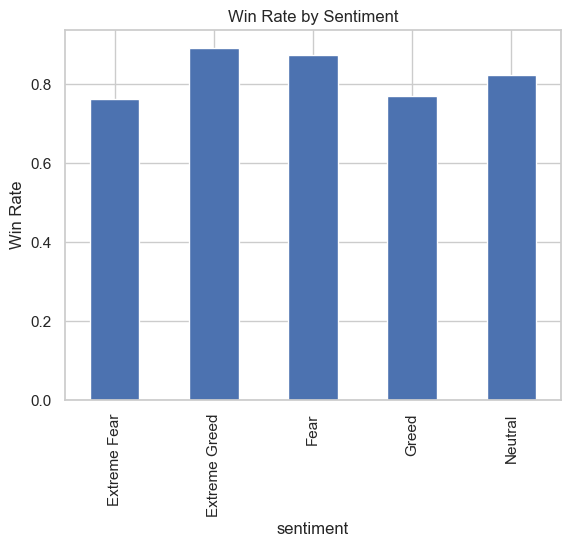

In [19]:
win_rate = merged.groupby('sentiment')['win'].mean()

win_rate.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

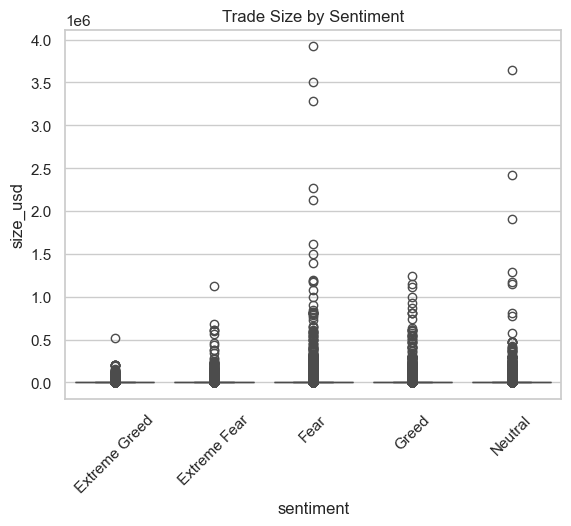

In [20]:
sns.boxplot(x='sentiment', y='size_usd', data=merged)
plt.title("Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()

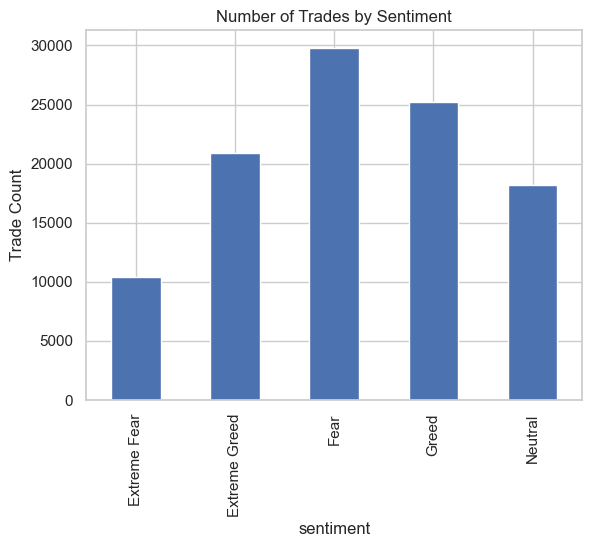

In [21]:
trade_freq = merged.groupby('sentiment').size()

trade_freq.plot(kind='bar')
plt.title("Number of Trades by Sentiment")
plt.ylabel("Trade Count")
plt.show()

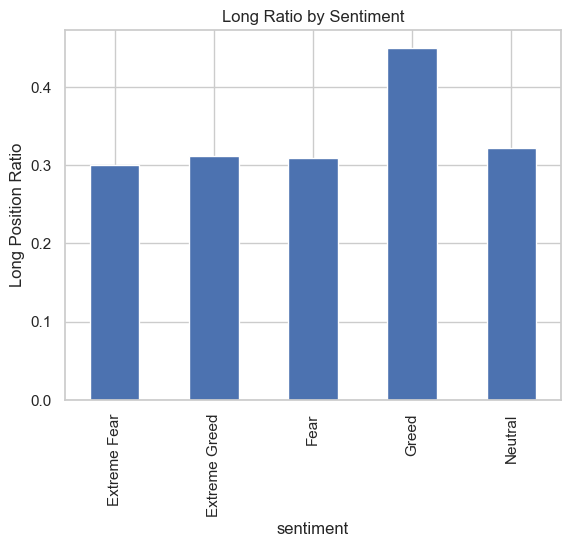

In [22]:
long_ratio = merged.groupby('sentiment')['is_long'].mean()

long_ratio.plot(kind='bar')
plt.title("Long Ratio by Sentiment")
plt.ylabel("Long Position Ratio")
plt.show()

In [23]:
account_trades = merged.groupby('account').size()

median_trades = account_trades.median()

trader_type = account_trades.apply(
    lambda x: 'Frequent' if x > median_trades else 'Infrequent'
)

merged['trader_type'] = merged['account'].map(trader_type)

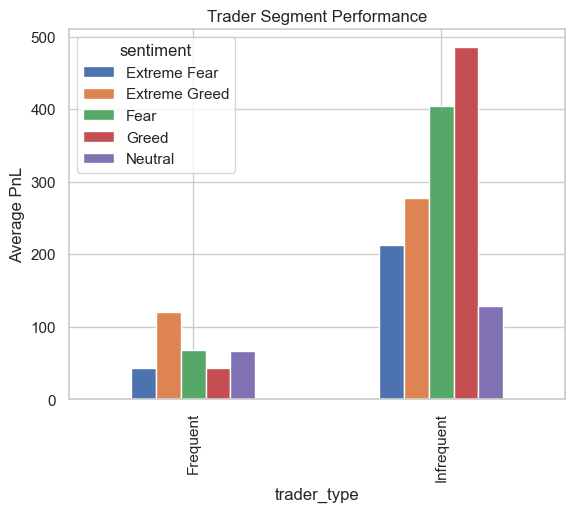

In [24]:
segment_perf = merged.groupby(['trader_type', 'sentiment'])['closedpnl'].mean().unstack()

segment_perf.plot(kind='bar')
plt.title("Trader Segment Performance")
plt.ylabel("Average PnL")
plt.show()

In [29]:
summary = merged.groupby('sentiment').agg({
    'closedpnl': 'mean',
    'win': 'mean',
    'size_usd': 'mean',
    'is_long': 'mean'
})

print(summary)

                closedpnl       win     size_usd   is_long
sentiment                                                 
Extreme Fear    71.027316  0.762156  5467.570419  0.300115
Extreme Greed  130.205309  0.891670  2779.563632  0.311706
Fear           112.625988  0.872886  8041.140445  0.309648
Greed           85.403927  0.768907  5438.671764  0.450548
Neutral         71.199993  0.823889  5556.444833  0.322760
